In [3]:
import pandas as pd
import seaborn as sns


In [5]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


<Axes: xlabel='cp', ylabel='count'>

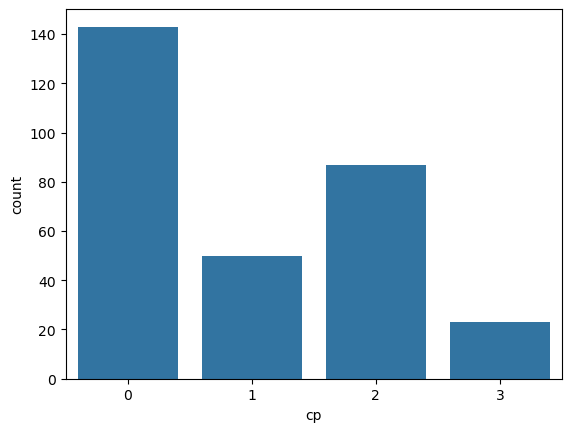

In [7]:
sns.countplot(x="cp",data=df)

<Axes: xlabel='cp', ylabel='count'>

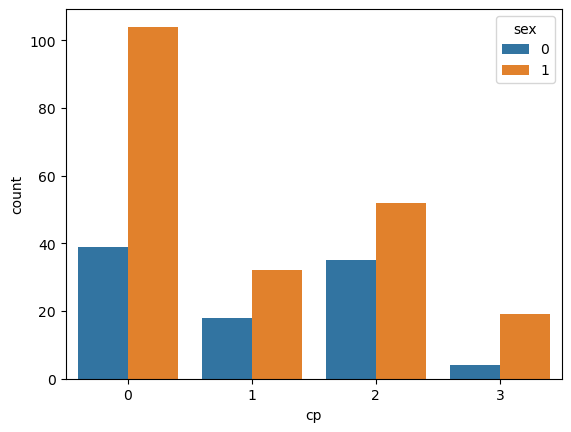

In [8]:
sns.countplot(x="cp",hue="sex",data=df)

<Axes: xlabel='fbs', ylabel='count'>

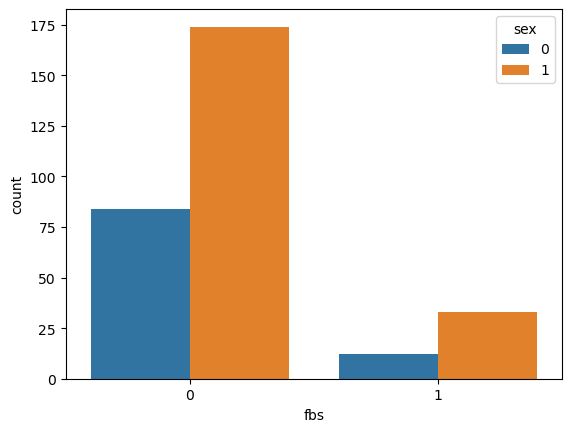

In [10]:
sns.countplot(x="fbs",hue="sex",data=df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


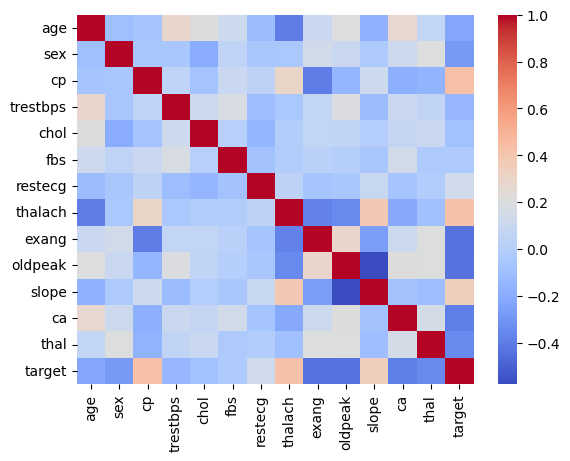

In [13]:
#matrice de corrélation des caractéristiques des patients.
corr =df.corr()
sns.heatmap(corr,cmap="coolwarm")
df

In [15]:
from sklearn.model_selection import train_test_split

x = df[["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]]
y = df["target"]
x_test , x_train , y_test , y_train = train_test_split(x,y,test_size=0.3)


In [16]:
from sklearn import tree 
abr = tree.DecisionTreeClassifier(max_depth=3 , min_samples_leaf =2)
abr=abr.fit(x_train,y_train)
abr

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)

In [19]:
y_pred=abr.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

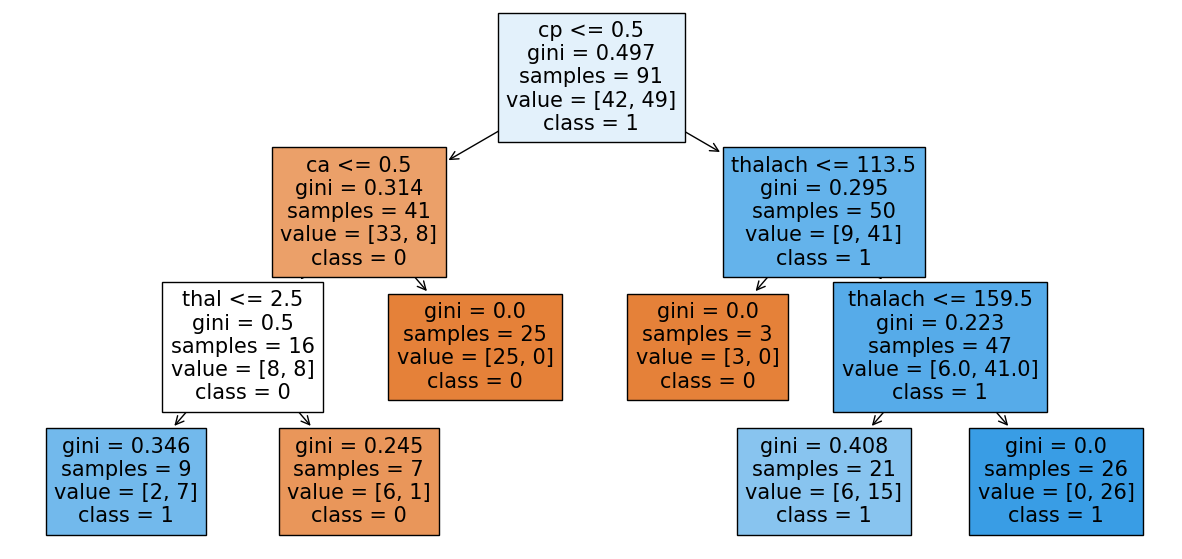

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,7))
fn = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]
cn=['0','1']
tree.plot_tree(abr,feature_names=fn,class_names=cn,filled=True)
plt.show()

In [23]:
from sklearn.metrics import accuracy_score
1-accuracy_score(y_test, y_pred)

0.19811320754716977

In [25]:
# 1ere méthode
print("Importance des features dans la décision : ", abr.feature_importances_)

Importance des features dans la décision :  [0.         0.         0.55264031 0.         0.         0.
 0.         0.19440166 0.         0.         0.         0.1532342
 0.09972384]


In [31]:
import numpy as np
importance = pd.DataFrame({'feature': x_train.columns,'importance' :
np.round(abr.feature_importances_,3)})
importance.sort_values('importance', ascending=False, inplace = True)
importance

,feature,importance
2,cp,0.553
7,thalach,0.194
11,ca,0.153
12,thal,0.100
0,age,0.000
1,sex,0.000
3,trestbps,0.000
4,chol,0.000
5,fbs,0.000
6,restecg,0.000


In [87]:
best_accuracy = 0
max_depth=0
min_samples_leaf=0
for i in  [1, 2, 4, 6,8, 10, 12]:
    for j in  [2, 3, 5, 10, 15, 20]:
        model = tree.DecisionTreeClassifier(max_depth=i , min_samples_leaf =j)
        model =model.fit(x_train,y_train)
        y_pred=model.predict(x_test)
        accuracy = accuracy_score(y_test, y_pred)
        print("i = ",i," et j = ",j," accuracy = ",accuracy)
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            max_depth=i
            min_samples_leaf=j
print("the best_accuracy = ",best_accuracy," for max_depth = ",max_depth," et min_samples_leaf = ",min_samples_leaf)
            

i =  1  et j =  2  accuracy =  0.7358490566037735
i =  1  et j =  3  accuracy =  0.7358490566037735
i =  1  et j =  5  accuracy =  0.7358490566037735
i =  1  et j =  10  accuracy =  0.7358490566037735
i =  1  et j =  15  accuracy =  0.7358490566037735
i =  1  et j =  20  accuracy =  0.7358490566037735
i =  2  et j =  2  accuracy =  0.7311320754716981
i =  2  et j =  3  accuracy =  0.7311320754716981
i =  2  et j =  5  accuracy =  0.7358490566037735
i =  2  et j =  10  accuracy =  0.7358490566037735
i =  2  et j =  15  accuracy =  0.7358490566037735
i =  2  et j =  20  accuracy =  0.7358490566037735
i =  4  et j =  2  accuracy =  0.6745283018867925
i =  4  et j =  3  accuracy =  0.7122641509433962
i =  4  et j =  5  accuracy =  0.7877358490566038
i =  4  et j =  10  accuracy =  0.6886792452830188
i =  4  et j =  15  accuracy =  0.7358490566037735
i =  4  et j =  20  accuracy =  0.7358490566037735
i =  6  et j =  2  accuracy =  0.7028301886792453
i =  6  et j =  3  accuracy =  0.75943396

In [89]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [1, 2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [2, 3, 5, 10, 15, 20]
}
dt_model = tree.DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")

Meilleurs hyperparamètres : {'max_depth': 6, 'min_samples_leaf': 2}


In [91]:
model = tree.DecisionTreeClassifier(max_depth=6 , min_samples_leaf =5)
model =model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy de Q9 = ",accuracy)

model2 = tree.DecisionTreeClassifier(max_depth=6 , min_samples_leaf =2)
model2 =model2.fit(x_train,y_train)
y_pred2=model.predict(x_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print("accuracy de GridSearchCV = ",accuracy2)

accuracy de Q9 =  0.7877358490566038
accuracy de GridSearchCV =  0.7877358490566038
